In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Visão Geral do Dataset

In [2]:
df = pd.read_csv('../data/raw/mental_health.csv')
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [3]:
df.shape

(2000, 18)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   str    
 3   Occupation                2000 non-null   str    
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   str    
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol            

# Qualidade dos Dados

In [33]:
print('Valores nulo de cada coluna:')
df.isnull().sum()

Valores nulo de cada coluna:


Person_ID                   0
Age                         0
Gender                      0
Occupation                  0
Daily_Screen_Time           0
Social_Media_Usage          0
Night_Usage                 0
Sleep_Hours                 0
Stress_Level                0
Work_Study_Hours            0
Physical_Activity           0
Social_Interaction_Score    0
Caffeine_Intake             0
Smoking                     0
Alcohol                     0
Depression                  0
Anxiety                     0
Burnout                     0
dtype: int64

In [6]:
df.nunique()

Person_ID                   2000
Age                           44
Gender                         2
Occupation                     3
Daily_Screen_Time            101
Social_Media_Usage            71
Night_Usage                    2
Sleep_Hours                   61
Stress_Level                  10
Work_Study_Hours             101
Physical_Activity              3
Social_Interaction_Score      10
Caffeine_Intake                5
Smoking                        2
Alcohol                        2
Depression                     2
Anxiety                        2
Burnout                        2
dtype: int64

In [34]:
print('Número de valores duplicados:', df.duplicated().sum())

Número de valores duplicados: 0


In [7]:
df['Smoking'] = df['Smoking'].astype(bool)
df['Night_Usage'] = df['Night_Usage'].astype(bool)
df['Alcohol'] = df['Alcohol'].astype(bool)
df['Depression'] = df['Depression'].astype(bool)
df['Anxiety'] = df['Anxiety'].astype(bool)
df['Burnout'] = df['Burnout'].astype(bool)

# Estatísticas Descritivas

In [8]:
df.describe()

,Person_ID,Age,Daily_Screen_Time,Social_Media_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,37.694000,6.943150,4.436400,6.00765,5.409500,7.005650,5.488000,2.029500
std,577.494589,12.614195,2.882415,2.011725,1.70631,2.885129,2.846442,2.885484,1.432709
min,1.000000,16.000000,2.000000,1.000000,3.00000,1.000000,2.000000,1.000000,0.000000
25%,500.750000,27.000000,4.500000,2.700000,4.60000,3.000000,4.500000,3.000000,1.000000
50%,1000.500000,38.000000,6.800000,4.400000,6.00000,5.000000,7.100000,6.000000,2.000000
75%,1500.250000,49.000000,9.400000,6.200000,7.50000,8.000000,9.400000,8.000000,3.000000
max,2000.000000,59.000000,12.000000,8.000000,9.00000,10.000000,12.000000,10.000000,4.000000


# Distribuição das Variavéis

Text(0.5, 1.0, 'Distribution of Gender')

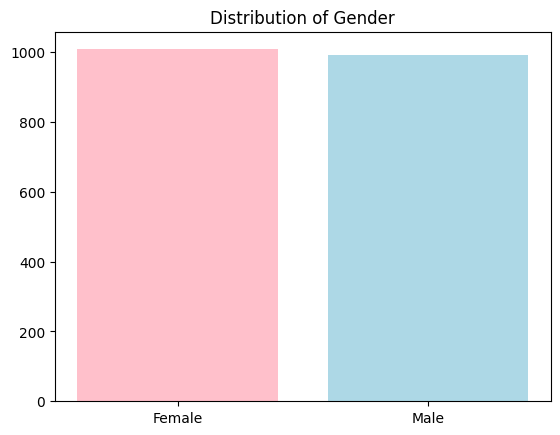

In [9]:
plt.bar(
    df['Gender'].value_counts().index, 
    df['Gender'].value_counts().values,
    color=['pink', 'lightblue']
)
plt.title('Distribution of Gender')

Text(0.5, 1.0, 'Distribution of Occupation')

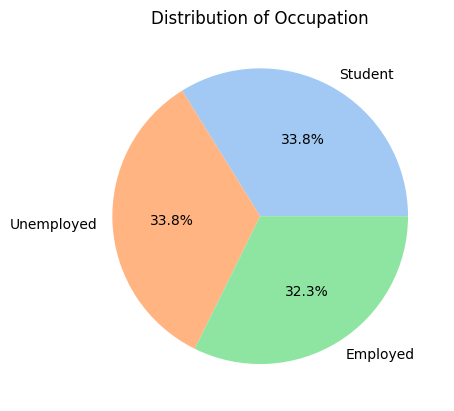

In [10]:
df['Occupation'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribution of Occupation')

Text(0.5, 1.0, 'Physical Activity Distribution')

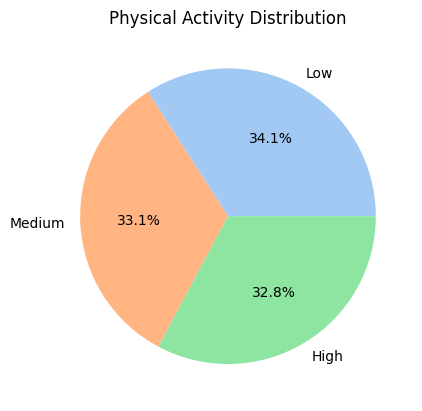

In [11]:
df['Physical_Activity'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Physical Activity Distribution')

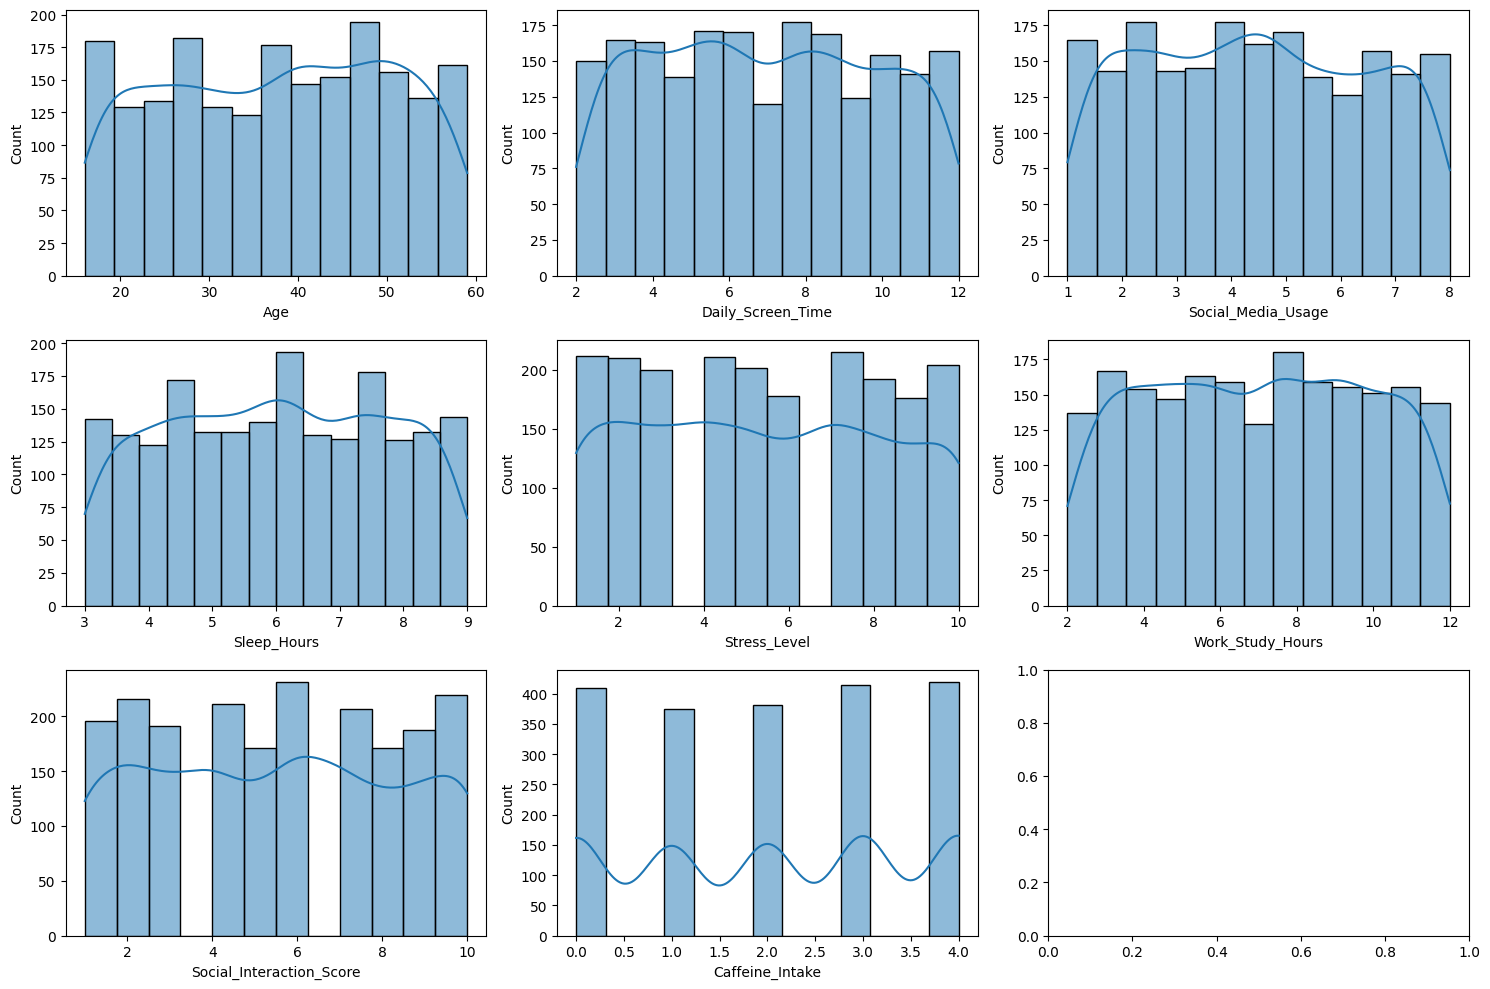

In [35]:
variaveis_numericas = df.select_dtypes(include=['int64', 'float64']).columns
variaveis_numericas = variaveis_numericas.drop('Person_ID')
f"Temos {len(variaveis_numericas)} variaveis numéricas: {', '.join(variaveis_numericas)}"

f, axes = plt.subplots(3, 3, figsize=(15, 10))

line = 0
column = 0

for i in variaveis_numericas:
    sns.histplot(x=i, data=df, ax=axes[line][column], kde=True)
    column += 1
    if column == 3:
        column = 0
        line += 1

In [42]:
df[variaveis_numericas].corr()

,Age,Daily_Screen_Time,Social_Media_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Social_Interaction_Score,Caffeine_Intake
Age,1.000000,0.022780,0.005971,-0.007508,-0.021641,-0.010563,-0.004898,-0.018046
Daily_Screen_Time,0.022780,1.000000,0.009846,-0.020927,-0.007215,0.045373,-0.009859,-0.027237
Social_Media_Usage,0.005971,0.009846,1.000000,-0.025580,-0.003526,0.003238,-0.014523,0.006257
Sleep_Hours,-0.007508,-0.020927,-0.025580,1.000000,-0.028459,0.025024,-0.026129,-0.057676
Stress_Level,-0.021641,-0.007215,-0.003526,-0.028459,1.000000,-0.022692,0.005909,-0.011395
Work_Study_Hours,-0.010563,0.045373,0.003238,0.025024,-0.022692,1.000000,0.032006,0.001345
Social_Interaction_Score,-0.004898,-0.009859,-0.014523,-0.026129,0.005909,0.032006,1.000000,0.026405
Caffeine_Intake,-0.018046,-0.027237,0.006257,-0.057676,-0.011395,0.001345,0.026405,1.000000


# Analise da variavel alvo: Depressão

In [ ]:
df.groupby('Depression').size()

Depression
False    1002
True      998
dtype: int64

Text(0.5, 0, 'Depression')

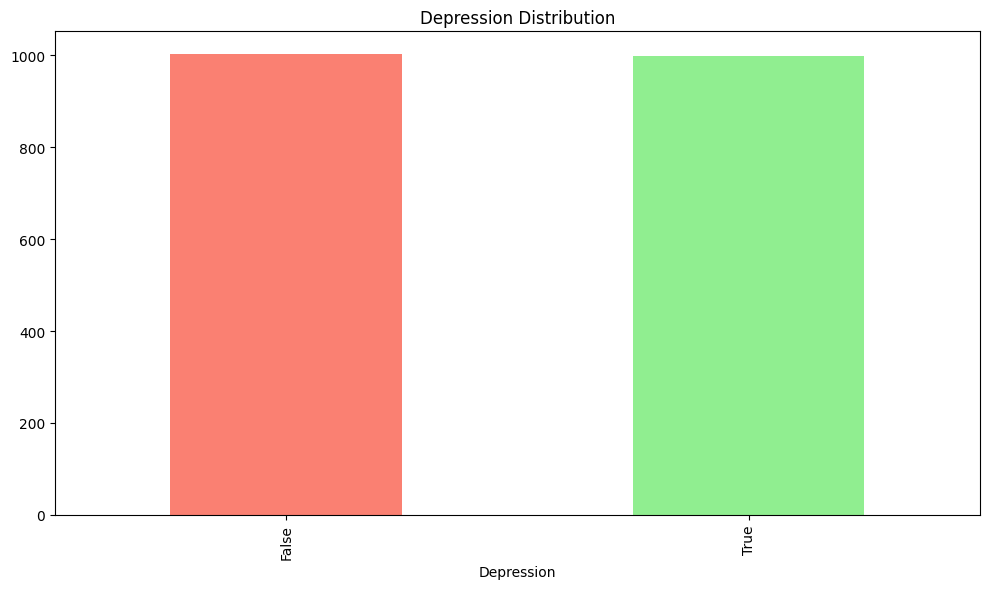

In [39]:
df.Depression.value_counts().plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title('Depression Distribution')
plt.xlabel('Depression')

# Relação de cada variável x variável alvo

In [14]:
# Set figure size and layout
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.autolayout'] = True

Text(0, 0.5, 'Frequency')

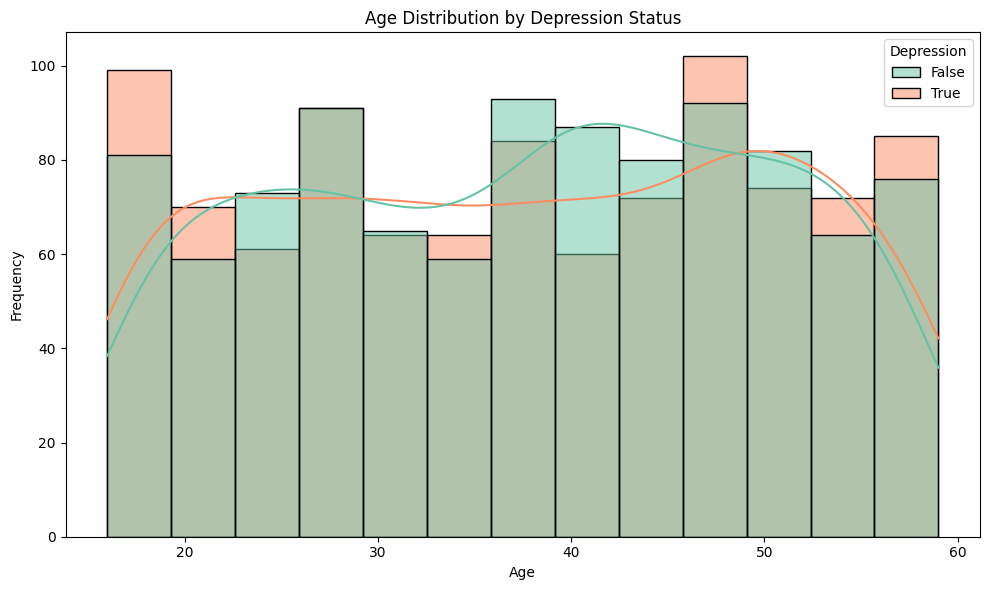

In [15]:
sns.histplot(df, x='Age', hue='Depression', palette='Set2', multiple="layer", kde=True)
plt.title('Age Distribution by Depression Status')
plt.xlabel('Age')
plt.ylabel('Frequency')

Text(0, 0.5, 'Depression Rate')

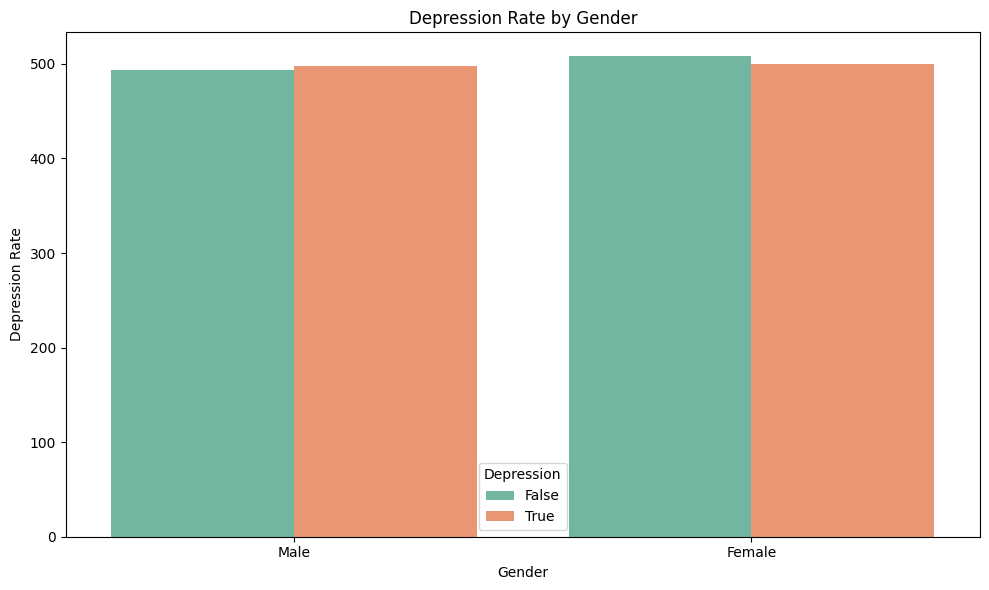

In [16]:
sns.countplot(x='Gender', hue='Depression', data=df, palette='Set2')
plt.title('Depression Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Depression Rate')

Text(0.5, 28.999999999999986, 'Occupation')

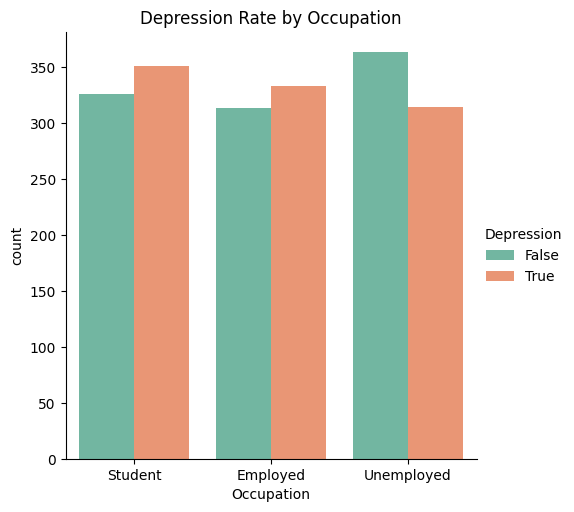

In [29]:
sns.catplot(x='Occupation', hue='Depression', data=df, kind='count', palette='Set2')
plt.title('Depression Rate by Occupation')
plt.xlabel('Occupation')

Text(0, 0.5, 'Frequency')

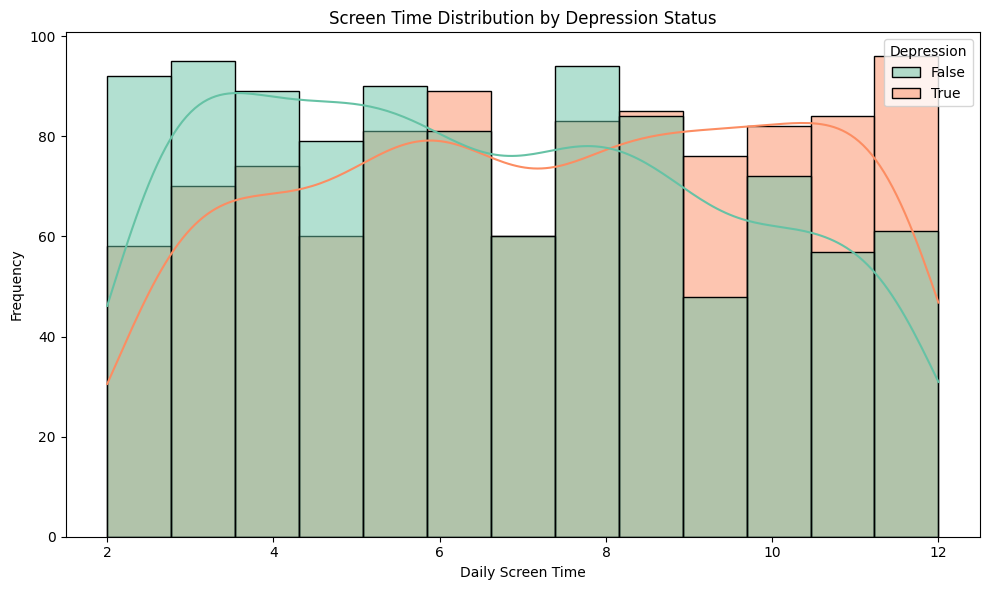

In [18]:
sns.histplot(df, x='Daily_Screen_Time', hue='Depression', kde=True, palette='Set2')
plt.title('Screen Time Distribution by Depression Status')
plt.xlabel('Daily Screen Time')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

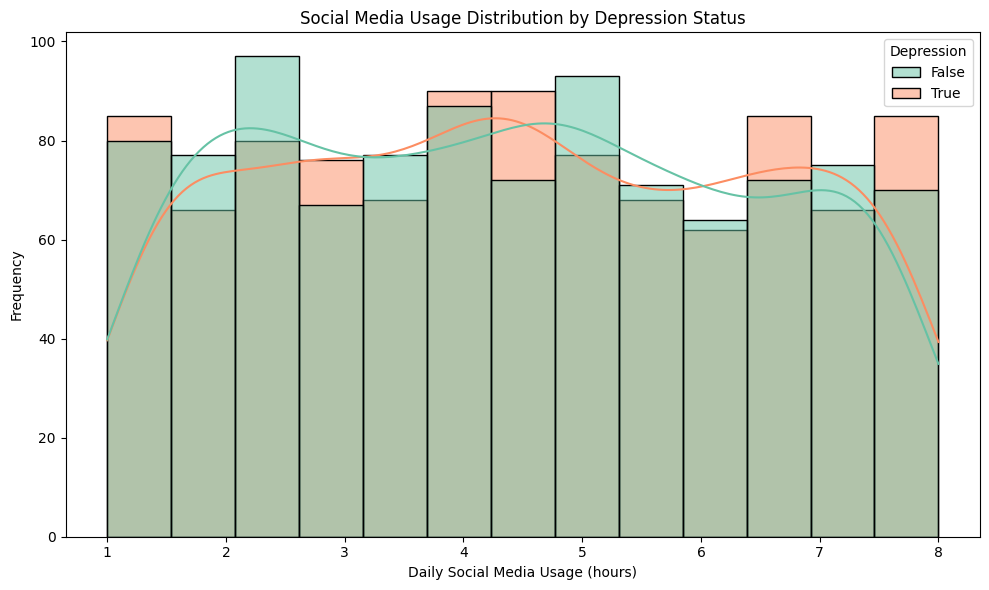

In [19]:
sns.histplot(df, x='Social_Media_Usage', hue='Depression', kde=True, palette='Set2')
plt.title('Social Media Usage Distribution by Depression Status')
plt.xlabel('Daily Social Media Usage (hours)')
plt.ylabel('Frequency')

Text(0.5, 0, 'Sleep Hours')

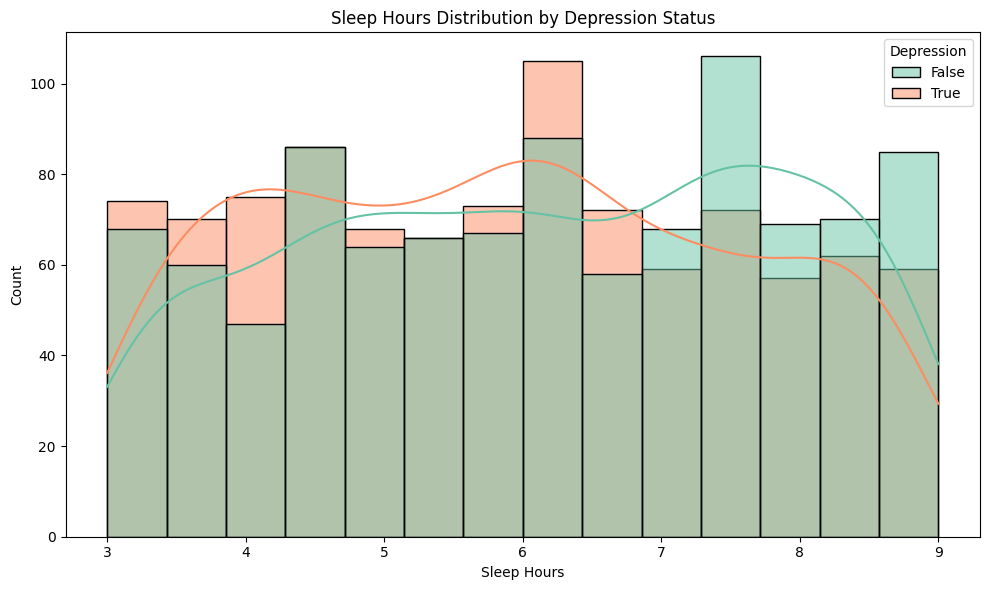

In [20]:
sns.histplot(df, x='Sleep_Hours', hue='Depression', kde=True, palette='Set2')
plt.title('Sleep Hours Distribution by Depression Status')
plt.xlabel('Sleep Hours')

Text(0, 0.5, 'Frequency')

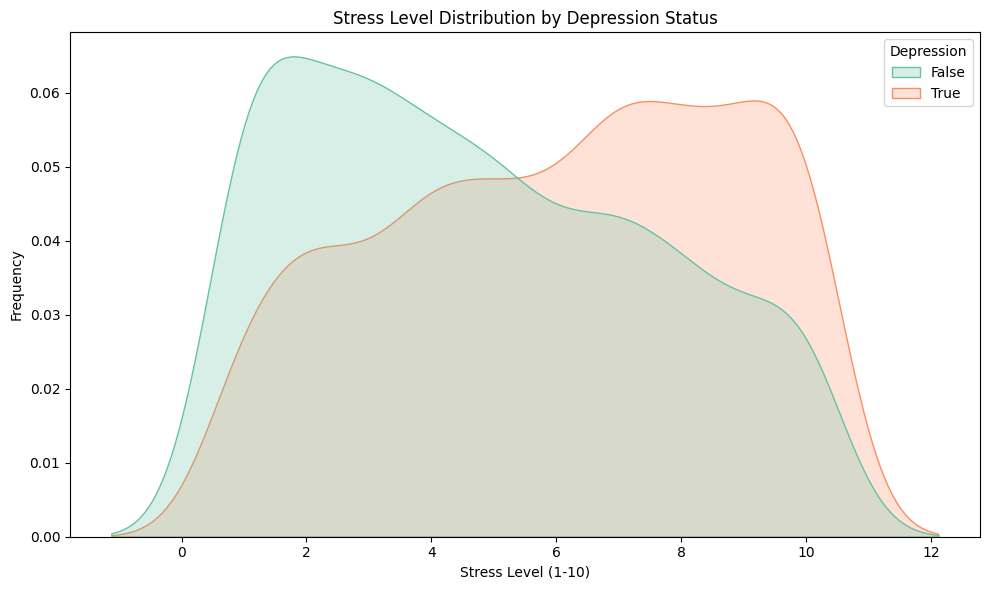

In [30]:
sns.kdeplot(x='Stress_Level', hue='Depression', data=df, palette='Set2', fill=True)
plt.title('Stress Level Distribution by Depression Status')
plt.xlabel('Stress Level (1-10)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

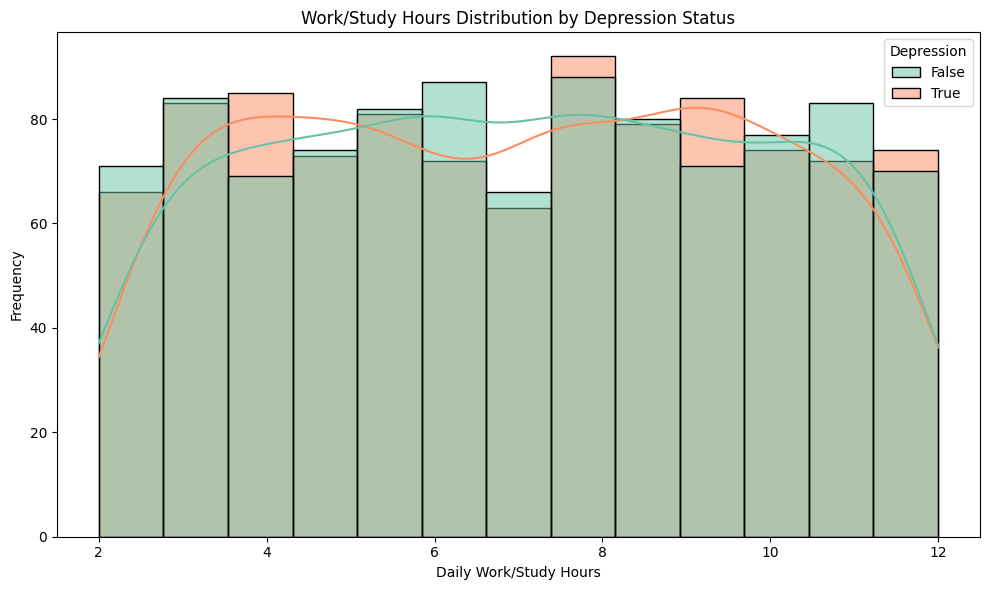

In [22]:
sns.histplot(df, x='Work_Study_Hours', hue='Depression', kde=True, palette='Set2')
plt.title('Work/Study Hours Distribution by Depression Status')
plt.xlabel('Daily Work/Study Hours')
plt.ylabel('Frequency')

<Axes: xlabel='Physical_Activity', ylabel='count'>

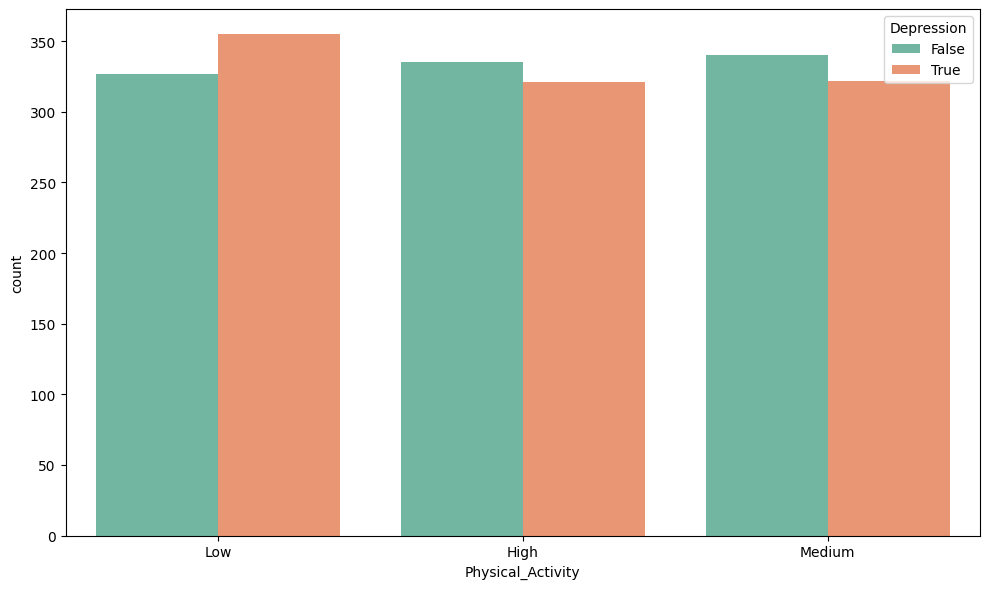

In [23]:
sns.countplot(x='Physical_Activity', hue='Depression', data=df, palette='Set2')

Text(0, 0.5, 'Frequency')

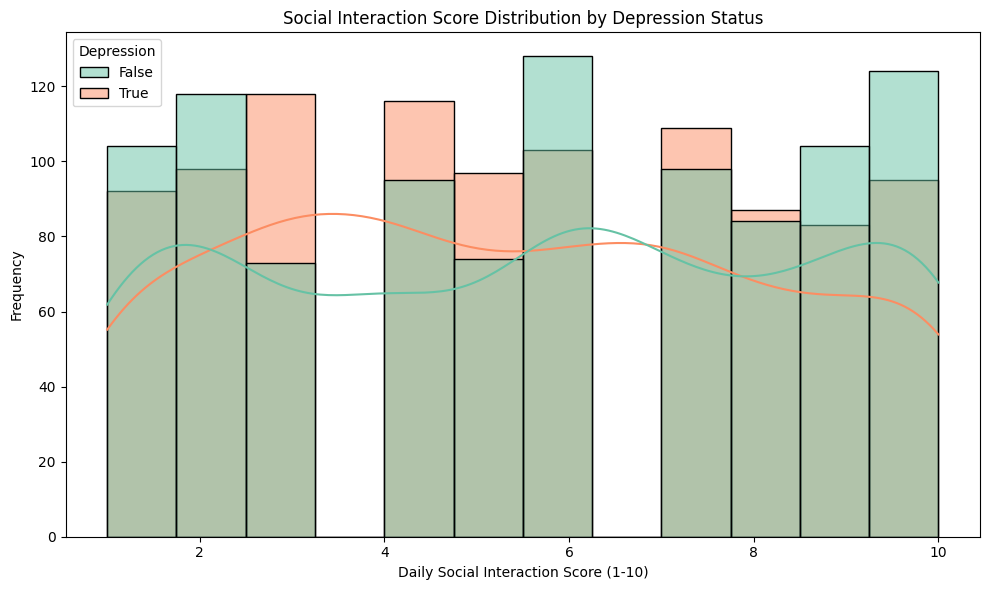

In [24]:
sns.histplot(df, x='Social_Interaction_Score', hue='Depression', kde=True, palette='Set2')
plt.title('Social Interaction Score Distribution by Depression Status')
plt.xlabel('Daily Social Interaction Score (1-10)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

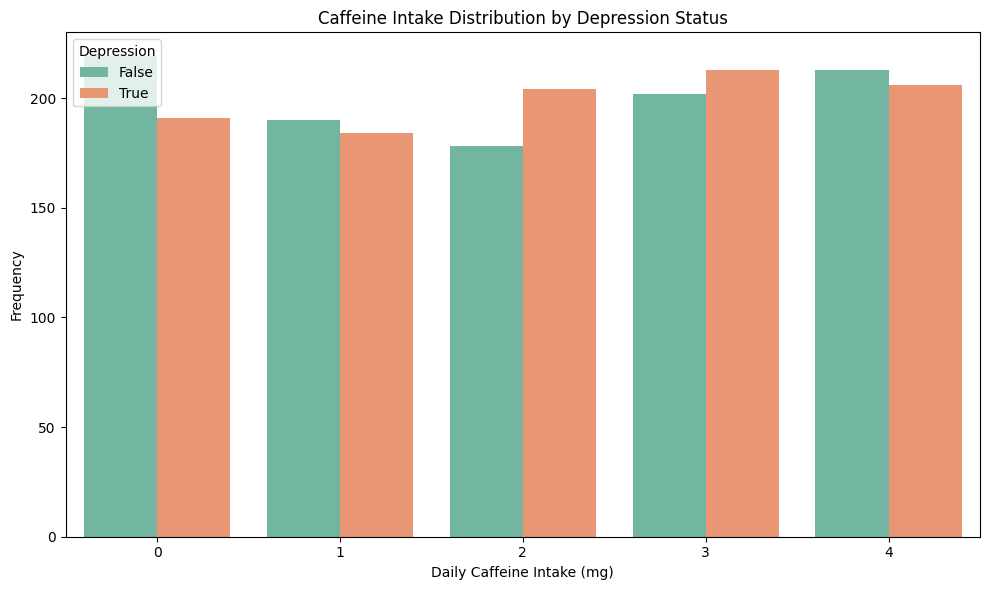

In [25]:
sns.countplot(df, x='Caffeine_Intake', hue='Depression', palette='Set2')
plt.title('Caffeine Intake Distribution by Depression Status')
plt.xlabel('Daily Caffeine Intake (mg)')
plt.ylabel('Frequency')

# Avaliar outliers

In [26]:
variaveis_numericas = df.select_dtypes(include=['int64', 'float64']).columns
variaveis_numericas = variaveis_numericas.drop('Person_ID')
f"Temos {len(variaveis_numericas)} variaveis numéricas: {', '.join(variaveis_numericas)}"

'Temos 8 variaveis numéricas: Age, Daily_Screen_Time, Social_Media_Usage, Sleep_Hours, Stress_Level, Work_Study_Hours, Social_Interaction_Score, Caffeine_Intake'

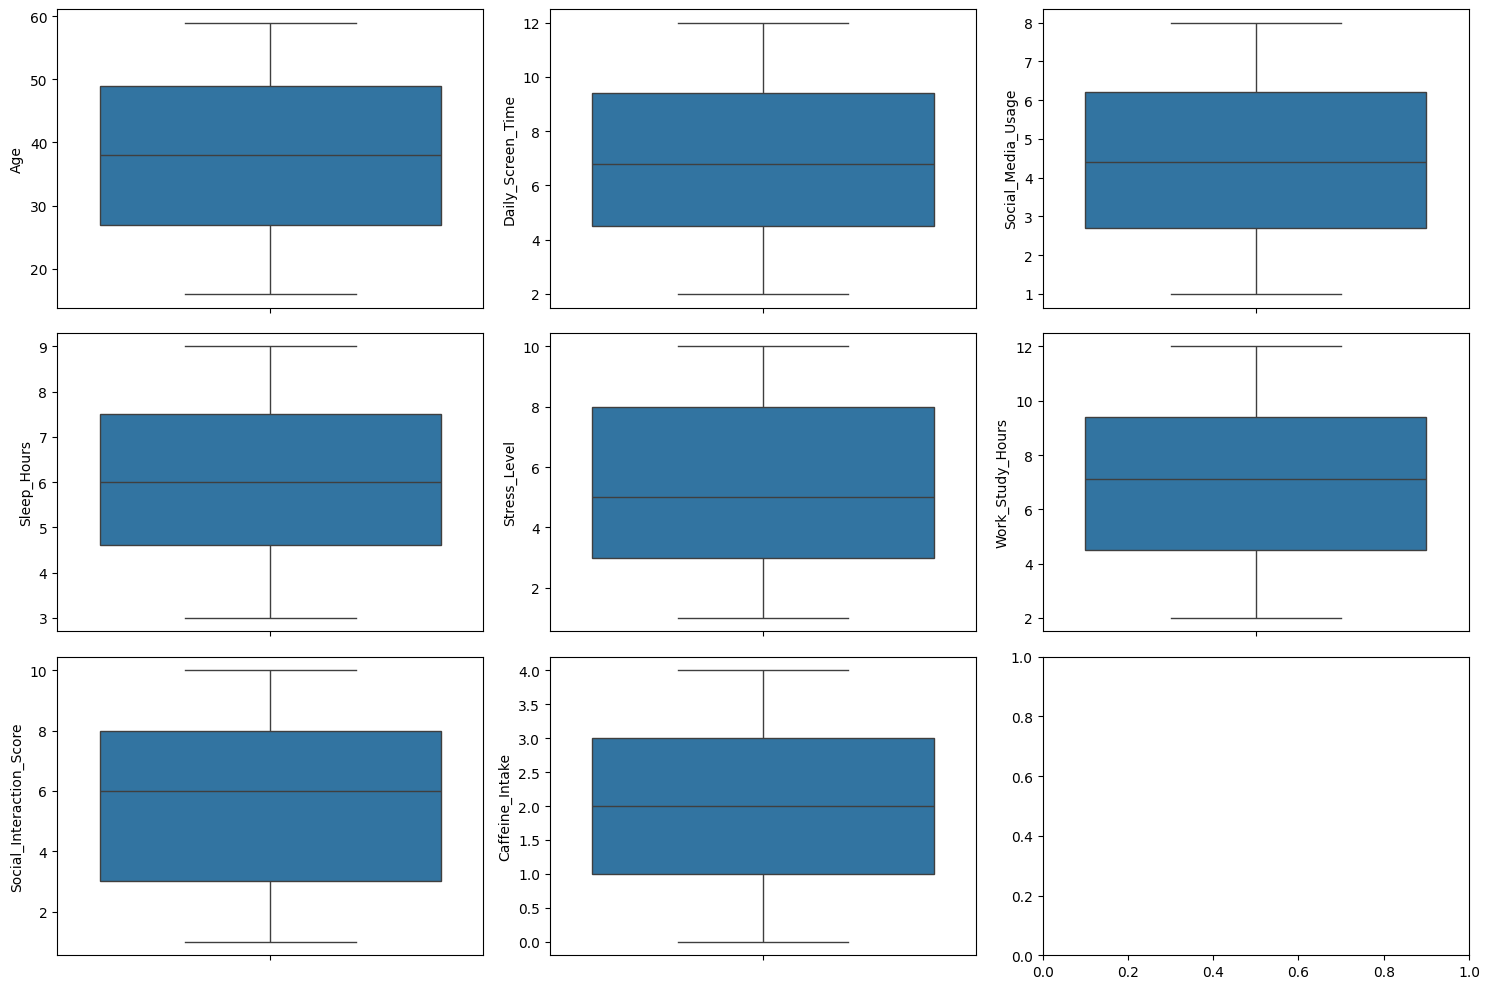

In [27]:
f, axes = plt.subplots(3, 3, figsize=(15, 10))

line = 0
column = 0
for i in variaveis_numericas:
    sns.boxplot(y=i, data=df, ax=axes[line][column])
    column += 1
    if column == 3:
        column = 0
        line += 1